Question A — Corpus scale & table density. Answers: how many images/tuples, the tuples-per-image distribution, and how images split into sparse/medium/dense bands (with each band's share of total tuples).

images = 57   tuples = 866
tuples/image  mean 15.19  std 9.90  min 1  Q1 8  median 16  Q3 18  max 48


,images,image_%,tuples,tuple_%
band,,,,
sparse (1-9),19,33.3,106,12.2
medium (10-20),29,50.9,472,54.5
dense (21+),9,15.8,288,33.3



5 sparsest: [('111.jpeg', 1), ('112.jpeg', 1), ('78.jpeg', 2), ('106.PNG', 2), ('9.jpeg', 4)]
5 densest : [('59.PNG', 28), ('68.jpeg', 34), ('34.PNG', 40), ('15.PNG', 42), ('20.PNG', 48)]


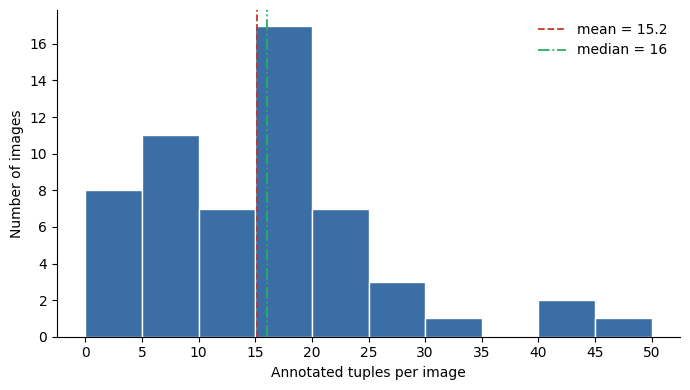

saved figures\fig_tuples_per_image.png


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# --- config: point this at your ground-truth CSV ---------------------------
CSV_PATH = "test_set_normalized.csv"   # or full path, e.g. r"C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\test_set_normalized.csv"
FIG_DIR  = "figures"
FIG_PATH = os.path.join(FIG_DIR, "fig_tuples_per_image.png")

# --- load ------------------------------------------------------------------
df = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)
n_images = df["image_id"].nunique()
n_tuples = len(df)
tpi = df.groupby("image_id").size().sort_values()   # tuples per image

# --- headline statistics ---------------------------------------------------
d = tpi.describe()
print(f"images = {n_images}   tuples = {n_tuples}")
print(f"tuples/image  mean {d['mean']:.2f}  std {d['std']:.2f}  "
      f"min {int(d['min'])}  Q1 {d['25%']:.0f}  median {d['50%']:.0f}  "
      f"Q3 {d['75%']:.0f}  max {int(d['max'])}")

# --- density bands + tuple share -------------------------------------------
bands = [("sparse (1-9)",   (tpi <= 9)),
         ("medium (10-20)", (tpi >= 10) & (tpi <= 20)),
         ("dense (21+)",    (tpi >= 21))]
rows = []
for label, mask in bands:
    img, tup = int(mask.sum()), int(tpi[mask].sum())
    rows.append({"band": label,
                 "images": img, "image_%": round(100*img/n_images, 1),
                 "tuples": tup, "tuple_%": round(100*tup/n_tuples, 1)})
display(pd.DataFrame(rows).set_index("band"))

print("\n5 sparsest:", list(tpi.head(5).items()))
print("5 densest :", list(tpi.tail(5).items()))

# --- histogram (saves PNG for the thesis + renders inline) ------------------
os.makedirs(FIG_DIR, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(0, tpi.max() + 5, 5)
ax.hist(tpi.values, bins=bins, edgecolor="white", color="#3b6ea5")
ax.axvline(tpi.mean(),   color="#c0392b", linestyle="--", linewidth=1.3, label=f"mean = {tpi.mean():.1f}")
ax.axvline(tpi.median(), color="#27ae60", linestyle="-.", linewidth=1.3, label=f"median = {tpi.median():.0f}")
ax.set_xlabel("Annotated tuples per image")
ax.set_ylabel("Number of images")
ax.set_xticks(bins)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=200)
plt.show()
print(f"saved {FIG_PATH}")

unique nutrient names = 62
appear exactly once (hapax) = 15  (24.2% of vocabulary)
top  5 nutrients cover 447 tuples (51.6% of all tuples)
top 10 nutrients cover 644 tuples (74.4% of all tuples)
top 15 nutrients cover 713 tuples (82.3% of all tuples)

names with parentheses                = 1 rows, 1 unique
sub-nutrient markers (davon/of which) = 0 rows, 0 unique



,nutrient,count
0,Energy,152
1,Fat,76
2,Carbohydrate,76
3,Protein,76
4,Sugars,67
5,Saturated Fats,65
6,Salt,57
7,Fibre,36
8,Magnesium,20
9,Sodium,19


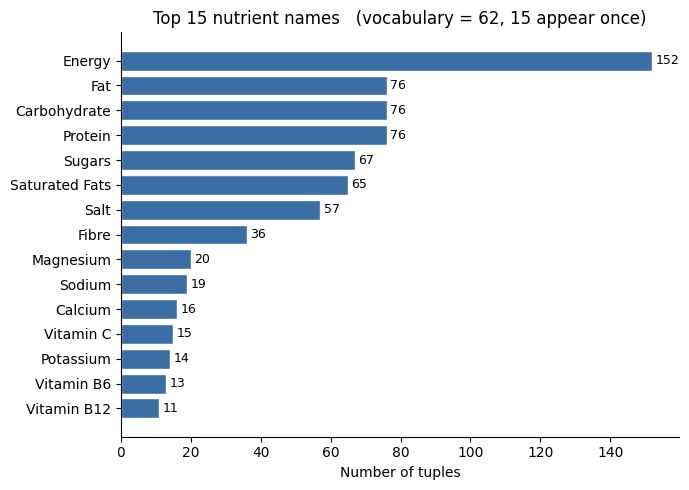

saved figures\fig_nutrient_frequency.png


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

CSV_PATH = "test_set_normalized.csv"
FIG_DIR  = "figures"
FIG_PATH = os.path.join(FIG_DIR, "fig_nutrient_frequency.png")
TOP_N    = 15

df  = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)
nut = df["nutrient"].str.strip()

# --- vocabulary size & long tail -------------------------------------------
vc    = nut.value_counts()
vocab = vc.size
hapax = int((vc == 1).sum())
print(f"unique nutrient names = {vocab}")
print(f"appear exactly once (hapax) = {hapax}  ({100*hapax/vocab:.1f}% of vocabulary)")

# --- head domination: top-K share of all tuples ----------------------------
for k in (5, 10, 15):
    cov = vc.head(k).sum()
    print(f"top {k:>2} nutrients cover {cov} tuples ({100*cov/len(df):.1f}% of all tuples)")
print()

# --- naming structure (self-reports; may be ~0 on normalized GT) ------------
has_paren   = nut.str.contains(r"\(")
sub_markers = nut.str.lower().str.contains(r"davon|of which|thereof|darunter")
print(f"names with parentheses                = {int(has_paren.sum())} rows, {nut[has_paren].nunique()} unique")
print(f"sub-nutrient markers (davon/of which) = {int(sub_markers.sum())} rows, {nut[sub_markers].nunique()} unique")
print()

# --- full top-N table ------------------------------------------------------
display(vc.head(TOP_N).rename_axis("nutrient").reset_index(name="count"))

# --- figure: top-N nutrient frequency --------------------------------------
os.makedirs(FIG_DIR, exist_ok=True)
top = vc.head(TOP_N)[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top.index, top.values, color="#3b6ea5", edgecolor="white")
for y, v in enumerate(top.values):
    ax.text(v + 1, y, str(v), va="center", fontsize=9)
ax.set_xlabel("Number of tuples")
ax.set_title(f"Top {TOP_N} nutrient names   (vocabulary = {vocab}, {hapax} appear once)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=200)
plt.show()
print(f"saved {FIG_PATH}")

Question C — Quantity characteristics. Answers: numeric range and how many orders of magnitude the values span, plus a format taxonomy (plain number vs inequality < vs scientific notation).

format taxonomy:


,format,count
0,plain numeric,846
1,"inequality (<, >)",18
2,scientific notation,2


  inequality (<, >): ['< 0.1', '< 0.5', '<0.02', '<0.1', '<0.3']
  scientific notation: ['3.6 x 10^8']

numeric values parsed = 864 of 866  (excluded 2 non-numeric, 86 zero/neg)
min 0.02   max 1e+04   span = 5.7 orders of magnitude


,count,%
magnitude band,,
< 1,221,25.6
1-10,200,23.1
10-100,225,26.0
100-1000,172,19.9
>= 1000,46,5.3


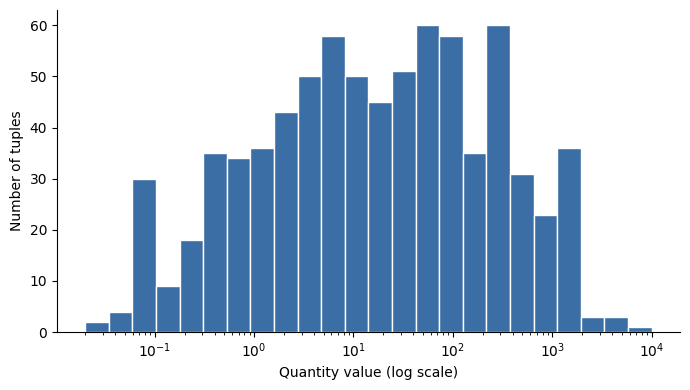

saved figures\fig_quantity_distribution.png


In [5]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

CSV_PATH = "test_set_normalized.csv"
FIG_DIR  = "figures"
FIG_PATH = os.path.join(FIG_DIR, "fig_quantity_distribution.png")

df = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)
q  = df["quantity"].str.strip()

# --- format taxonomy -------------------------------------------------------
def classify(s):
    if "<" in s or ">" in s:                 return "inequality (<, >)"
    if re.search(r"x\s*10|\^|[eE]\d", s):    return "scientific notation"
    try:
        float(s); return "plain numeric"
    except ValueError:
        return "other / non-numeric"

fmt = q.map(classify)
print("format taxonomy:")
display(fmt.value_counts().rename_axis("format").reset_index(name="count"))
for cat in ["inequality (<, >)", "scientific notation", "other / non-numeric"]:
    ex = sorted(q[fmt == cat].unique())[:6]
    if ex:
        print(f"  {cat}: {ex}")
print()

# --- numeric range & orders of magnitude -----------------------------------
def to_float(s):
    s = re.sub(r"[<>~]", "", s).strip()      # strip inequality markers
    try:
        return float(s)
    except ValueError:
        return np.nan

v   = q.map(to_float)
vv  = v.dropna()
pos = vv[vv > 0]
print(f"numeric values parsed = {vv.size} of {len(q)}  "
      f"(excluded {int((v.isna()).sum())} non-numeric, {int((vv<=0).sum())} zero/neg)")
print(f"min {pos.min():.4g}   max {pos.max():.4g}   "
      f"span = {np.log10(pos.max()/pos.min()):.1f} orders of magnitude")

oom = [("< 1", (vv < 1)), ("1-10", (vv >= 1) & (vv < 10)),
       ("10-100", (vv >= 10) & (vv < 100)), ("100-1000", (vv >= 100) & (vv < 1000)),
       (">= 1000", (vv >= 1000))]
display(pd.DataFrame([{"magnitude band": l, "count": int(m.sum()),
                       "%": round(100*int(m.sum())/vv.size, 1)} for l, m in oom]
                     ).set_index("magnitude band"))

# NOTE: decimal separator is NOT reported here -- comma->period was applied
# during normalization, so separator distribution is an artifact of this file,
# not a property of the dataset.

# --- figure: log-scale histogram -------------------------------------------
os.makedirs(FIG_DIR, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 25)
ax.hist(pos, bins=bins, edgecolor="white", color="#3b6ea5")
ax.set_xscale("log")
ax.set_xlabel("Quantity value (log scale)")
ax.set_ylabel("Number of tuples")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=200)
plt.show()
print(f"saved {FIG_PATH}")

Question D — Unit inventory. Answers: how many distinct units, how concentrated the distribution is (top-K coverage), and which units form the rare composite/derived tail

distinct units = 11


,unit,count,%
0,g,481,55.5
1,mg,171,19.7
2,kcal,76,8.8
3,kJ,75,8.7
4,µg,41,4.7
5,mg α-TE,6,0.7
6,mg NE,6,0.7
7,µg RE,4,0.5
8,I.E.,3,0.3
9,KBE,2,0.2


top 1 units cover 481 tuples (55.5%)
top 3 units cover 728 tuples (84.1%)
top 5 units cover 844 tuples (97.5%)

rare tail (6 units, count<=6): 22 tuples (2.5%)
  -> ['mg α-TE', 'mg NE', 'µg RE', 'I.E.', 'KBE', '(none)']


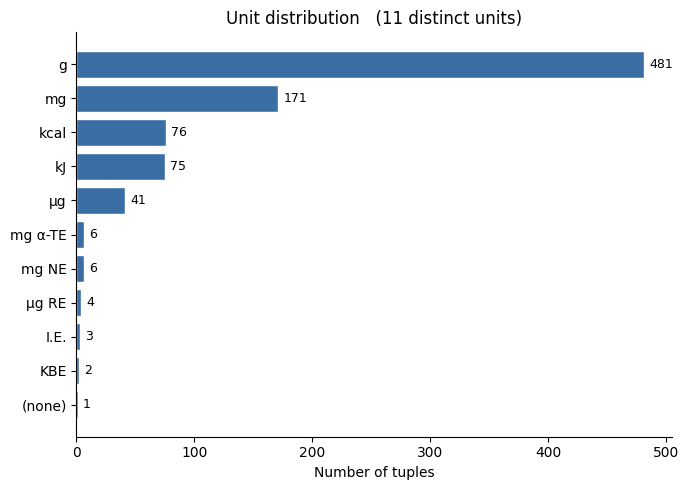

saved figures\fig_unit_distribution.png


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CSV_PATH = "test_set_normalized.csv"
FIG_DIR  = "figures"
FIG_PATH = os.path.join(FIG_DIR, "fig_unit_distribution.png")

df = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False, encoding="utf-8")
u  = df["unit"].str.strip().replace("", "(none)")

# --- full frequency table --------------------------------------------------
uc    = u.value_counts()
total = len(u)
tbl = uc.rename_axis("unit").reset_index(name="count")
tbl["%"] = (100 * tbl["count"] / total).round(1)
print(f"distinct units = {uc.size}")
display(tbl)

# --- concentration: top-K coverage -----------------------------------------
for k in (1, 3, 5):
    cov = uc.head(k).sum()
    print(f"top {k} units cover {cov} tuples ({100*cov/total:.1f}%)")
print()

# --- rare / composite tail (count <= 6) ------------------------------------
# these are derived-equivalent + specialist units: mg a-TE, mg NE, ug RE,
# I.E. (IU), KBE (CFU), and the blank -- semantics the parser must preserve.
rare = uc[uc <= 6]
print(f"rare tail ({rare.size} units, count<=6): "
      f"{rare.sum()} tuples ({100*rare.sum()/total:.1f}%)")
print(f"  -> {list(rare.index)}")

# NOTE: unit surface forms are canonicalized in this file (e.g. mcg->ug),
# so this measures unit *categories*, not raw OCR strings.

# --- figure: unit frequency (counts annotated so rare bars stay legible) ----
os.makedirs(FIG_DIR, exist_ok=True)
order = uc[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(order.index, order.values, color="#3b6ea5", edgecolor="white")
for y, v in enumerate(order.values):
    ax.text(v + total*0.005, y, str(v), va="center", fontsize=9)
ax.set_xlabel("Number of tuples")
ax.set_title(f"Unit distribution   ({uc.size} distinct units)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=200)
plt.show()
print(f"saved {FIG_PATH}")

Question E — Context distribution & multi-column structure. This is the one that directly motivates graph matching. Answers: which context values exist and their frequency, how many images are single- vs multi-context, and which context sets co-occur (the parallel-column layouts).

distinct contexts = 4


,context,count,%
0,per_100g,381,44.0
1,per_serving,323,37.3
2,per_daily_dose,130,15.0
3,per_100ml,32,3.7


single-context images = 20
multi-context images  = 37  (64.9% of 57)


,distinct contexts per image,images
0,1,20
1,2,36
2,3,1


,context_set,images
0,per_100g + per_serving,27
1,per_100g,8
2,per_daily_dose,7
3,per_serving,5
4,per_daily_dose + per_serving,3
5,per_100ml + per_serving,3
6,per_100g + per_daily_dose,2
7,per_100g + per_daily_dose + per_serving,1
8,per_100ml + per_daily_dose,1


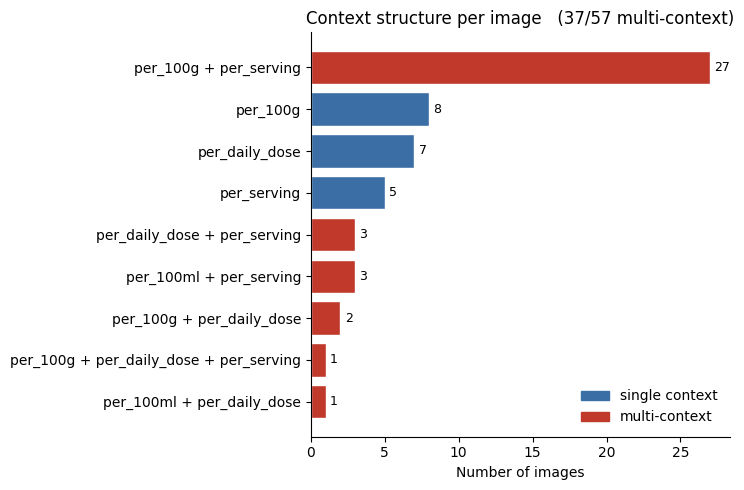

saved figures\fig_context_structure.png


In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

CSV_PATH = "test_set_normalized.csv"
FIG_DIR  = "figures"
FIG_PATH = os.path.join(FIG_DIR, "fig_context_structure.png")

df = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)
n_images = df["image_id"].nunique()

# --- context value frequency ----------------------------------------------
cc  = df["context"].str.strip().value_counts()
tbl = cc.rename_axis("context").reset_index(name="count")
tbl["%"] = (100 * tbl["count"] / len(df)).round(1)
print(f"distinct contexts = {cc.size}")
display(tbl)

# --- per-image context cardinality (single- vs multi-column) ---------------
sets  = df.groupby("image_id")["context"].apply(lambda s: tuple(sorted(s.unique())))
card  = sets.map(len)
multi = int((card >= 2).sum())
print(f"single-context images = {int((card == 1).sum())}")
print(f"multi-context images  = {multi}  ({100*multi/n_images:.1f}% of {n_images})")
display(card.value_counts().sort_index()
        .rename_axis("distinct contexts per image").reset_index(name="images"))

# --- context co-occurrence (which context SETS appear together) ------------
combos    = sets.value_counts()
combo_tbl = combos.rename_axis("context_set").reset_index(name="images")
combo_tbl["context_set"] = combo_tbl["context_set"].map(lambda t: " + ".join(t))
display(combo_tbl)

# NOTE: this property is genuinely dataset-intrinsic -- the number of parallel
# context columns per image reflects the source table layout, not normalization.

# --- figure: images per context-set (single=blue, multi=red) ---------------
os.makedirs(FIG_DIR, exist_ok=True)
labels = [" + ".join(t) for t in combos.index][::-1]
vals   = list(combos.values)[::-1]
colors = ["#c0392b" if " + " in l else "#3b6ea5" for l in labels]
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(labels, vals, color=colors, edgecolor="white")
for y, v in enumerate(vals):
    ax.text(v + 0.3, y, str(v), va="center", fontsize=9)
ax.set_xlabel("Number of images")
ax.set_title(f"Context structure per image   ({multi}/{n_images} multi-context)")
ax.legend(handles=[Patch(color="#3b6ea5", label="single context"),
                   Patch(color="#c0392b", label="multi-context")],
          frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=200)
plt.show()
print(f"saved {FIG_PATH}")

Question F — Repetition / one-to-many structure. This is the cleanest single piece of evidence that association ≠ ordinal row-matching. Answers: how often a nutrient repeats within an image, what share of all tuples that accounts for, and whether the repetition is cleanly context-driven (parallel columns) or not

(image, nutrient) pairs = 463


,"tuples per (image,nutrient)",pairs
0,1,140
1,2,278
2,3,12
3,4,32
4,6,1


repeated pairs (multiplicity > 1) = 323  (69.8% of pairs)
tuples belonging to a repeated nutrient = 726  (83.8% of all tuples)

repeated pairs separable by context (all distinct) = 280  (86.7% of repeated)
repeated pairs with same-context multiplicity       = 43  (13.3% of repeated)  <- context alone cannot separate


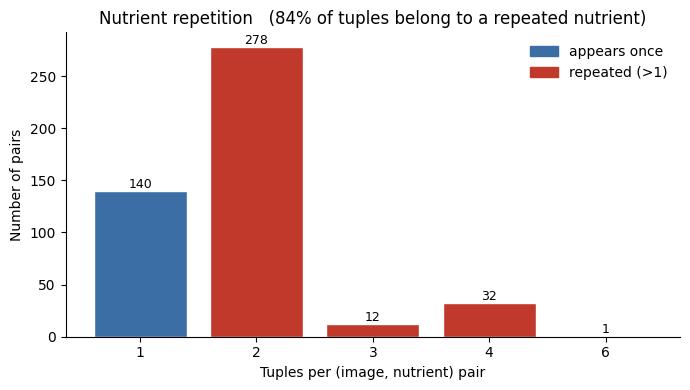

saved figures\fig_nutrient_repetition.png


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

CSV_PATH = "test_set_normalized.csv"
FIG_DIR  = "figures"
FIG_PATH = os.path.join(FIG_DIR, "fig_nutrient_repetition.png")

df = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)
n_tuples = len(df)

g    = df.groupby(["image_id", "nutrient"])
mult = g.size()                       # tuples per (image, nutrient) pair

# --- multiplicity distribution ---------------------------------------------
md = (mult.value_counts().sort_index()
      .rename_axis("tuples per (image,nutrient)").reset_index(name="pairs"))
print(f"(image, nutrient) pairs = {mult.size}")
display(md)

# --- headline: how much of the data is "repeated nutrient" -----------------
rep = mult[mult > 1]
print(f"repeated pairs (multiplicity > 1) = {rep.size}  ({100*rep.size/mult.size:.1f}% of pairs)")
print(f"tuples belonging to a repeated nutrient = {int(rep.sum())}  "
      f"({100*rep.sum()/n_tuples:.1f}% of all tuples)")
print()

# --- is the repetition context-driven (parallel columns) or ambiguous? -----
ctx_distinct = g["context"].nunique()
clean = int(((mult > 1) & (ctx_distinct == mult)).sum())   # all contexts distinct
ambig = int(((mult > 1) & (ctx_distinct <  mult)).sum())   # >=1 same-context repeat
print(f"repeated pairs separable by context (all distinct) = {clean}  "
      f"({100*clean/rep.size:.1f}% of repeated)")
print(f"repeated pairs with same-context multiplicity       = {ambig}  "
      f"({100*ambig/rep.size:.1f}% of repeated)  <- context alone cannot separate")

# --- figure: multiplicity distribution (single=blue, repeated=red) ---------
os.makedirs(FIG_DIR, exist_ok=True)
counts = mult.value_counts().sort_index()
colors = ["#3b6ea5" if k == 1 else "#c0392b" for k in counts.index]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor="white")
for x, v in enumerate(counts.values):
    ax.text(x, v + 3, str(v), ha="center", fontsize=9)
ax.set_xlabel("Tuples per (image, nutrient) pair")
ax.set_ylabel("Number of pairs")
ax.set_title(f"Nutrient repetition   "
             f"({100*rep.sum()/n_tuples:.0f}% of tuples belong to a repeated nutrient)")
ax.legend(handles=[Patch(color="#3b6ea5", label="appears once"),
                   Patch(color="#c0392b", label="repeated (>1)")], frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=200)
plt.show()
print(f"saved {FIG_PATH}")


Question G — Field completeness & metric justification. Answers: how complete each field is, what fraction of tuples carry all four core fields (the effective evaluation universe), and why the two sparse fields are structurally sparse rather than under-annotated.

,populated,blank,populated_%
field,,,
nutrient,866,0,100.0
quantity,866,0,100.0
unit,865,1,99.9
context,866,0,100.0
nrv_percent,175,691,20.2
serving_size,499,367,57.6


tuples with all 4 core fields populated = 865 (99.9%)  -> the 4F tuple is well-posed for ~every annotation

nrv_percent present on 175 tuples, 154 of them micronutrients (vitamins/minerals).
  -> blanks are STRUCTURAL: macronutrients carry no NRV%, the field is absent, not unannotated.

serving_size blank-rate by context (shows it is context-linked, not per-tuple):
context
per_100g           86.6
per_100ml         100.0
per_daily_dose      3.8
per_serving         0.0
  -> present on per_serving / per_daily_dose, absent on per_100g / per_100ml reference columns.


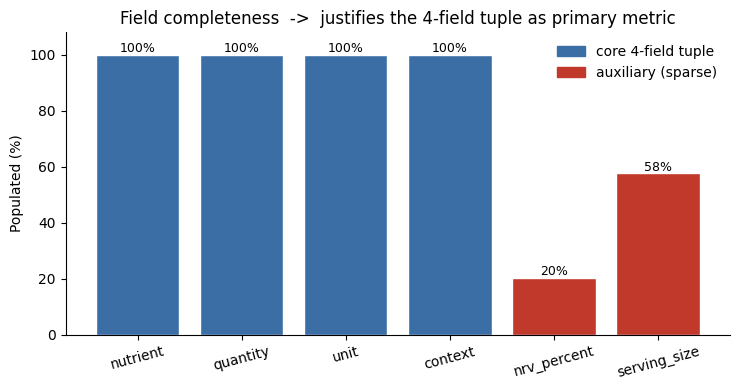

saved figures\fig_field_completeness.png


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

CSV_PATH = "test_set_normalized.csv"
FIG_DIR  = "figures"
FIG_PATH = os.path.join(FIG_DIR, "fig_field_completeness.png")

df = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)
n  = len(df)
fields = ["nutrient", "quantity", "unit", "context", "nrv_percent", "serving_size"]
core   = ["nutrient", "quantity", "unit", "context"]

def blank(c): return df[c].str.strip() == ""

# --- completeness per field ------------------------------------------------
rows = [{"field": c, "populated": n-int(blank(c).sum()),
         "blank": int(blank(c).sum()),
         "populated_%": round(100*(n-int(blank(c).sum()))/n, 1)} for c in fields]
display(pd.DataFrame(rows).set_index("field"))

# --- effective evaluation universe: all 4 core fields present --------------
allcore = ~(blank("nutrient") | blank("quantity") | blank("unit") | blank("context"))
print(f"tuples with all 4 core fields populated = {int(allcore.sum())} "
      f"({100*allcore.sum()/n:.1f}%)  -> the 4F tuple is well-posed for ~every annotation\n")

# --- why the two sparse fields are auxiliary, not 'missing data' ------------
has_nrv = ~blank("nrv_percent")
macros  = int(df.loc[has_nrv, "nutrient"].isin(["Energy","Fat","Carbohydrate","Protein"]).sum())
print(f"nrv_percent present on {int(has_nrv.sum())} tuples, "
      f"{int(has_nrv.sum())-macros} of them micronutrients (vitamins/minerals).")
print("  -> blanks are STRUCTURAL: macronutrients carry no NRV%, the field is absent, not unannotated.\n")

print("serving_size blank-rate by context (shows it is context-linked, not per-tuple):")
print((df.assign(b=blank("serving_size")).groupby("context")["b"].mean()*100).round(1).to_string())
print("  -> present on per_serving / per_daily_dose, absent on per_100g / per_100ml reference columns.")

# --- figure: completeness bar (core=blue, auxiliary=red) --------------------
os.makedirs(FIG_DIR, exist_ok=True)
pct    = [100*(n-int(blank(c).sum()))/n for c in fields]
colors = ["#3b6ea5" if c in core else "#c0392b" for c in fields]
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(fields, pct, color=colors, edgecolor="white")
for b, p in zip(bars, pct):
    ax.text(b.get_x()+b.get_width()/2, p+1, f"{p:.0f}%", ha="center", fontsize=9)
ax.set_ylabel("Populated (%)")
ax.set_ylim(0, 108)
ax.set_title("Field completeness  ->  justifies the 4-field tuple as primary metric")
ax.legend(handles=[Patch(color="#3b6ea5", label="core 4-field tuple"),
                   Patch(color="#c0392b", label="auxiliary (sparse)")], frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=15)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=200)
plt.show()
print(f"saved {FIG_PATH}")

Question H — Cross-field consistency. The last one — it's your defense against the "your model just memorized fixed mappings" objection. Three checks: whether unit is derivable from the nutrient, whether quantity is derivable from the nutrient, and whether context is derivable from the unit.

nutrients with >1 distinct unit = 15 of 62 (24.2%)  -> unit is NOT a fixed nutrient lookup


,nutrient,units
0,Energy,"[(none), kJ, kcal]"
1,Colecalciferol,"[mg, µg]"
2,Copper,"[mg, µg]"
3,L-Histidine,"[g, mg]"
4,L-Methionine,"[g, mg]"
5,L-Phenylalanine,"[g, mg]"
6,L-Tryptophan,"[g, mg]"
7,Magnesium,"[g, mg]"
8,Niacin,"[mg, mg NE]"
9,Sodium,"[g, mg]"



nutrients seen in >=2 images = 33
distinct quantity values per such nutrient: mean 17.6  median 8  max 121
  -> the same nutrient takes many different quantities; it CANNOT be looked up, only associated from the image.

unit x context (top units span all contexts -> context is not derivable from unit):
context  per_100g  per_100ml  per_daily_dose  per_serving
unit                                                     
g             237         24              23          197
mg             54          0              63           54
µg             11          0              25            5


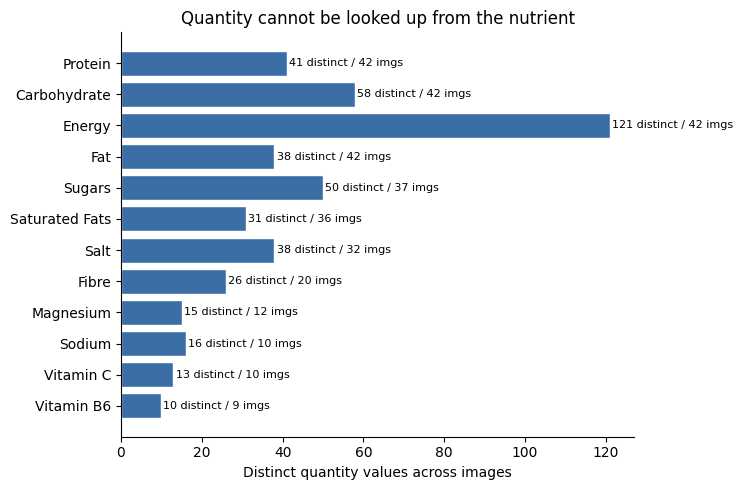

saved figures\fig_nutrient_quantity_diversity.png


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CSV_PATH = "test_set_normalized.csv"
FIG_DIR  = "figures"
FIG_PATH = os.path.join(FIG_DIR, "fig_nutrient_quantity_diversity.png")
TOP_N    = 12

df = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)

# === 1. nutrient -> unit is NOT one-to-one =================================
u_per_n = df.groupby("nutrient")["unit"].nunique()
multi   = u_per_n[u_per_n > 1].sort_values(ascending=False)
print(f"nutrients with >1 distinct unit = {multi.size} of {u_per_n.size} "
      f"({100*multi.size/u_per_n.size:.1f}%)  -> unit is NOT a fixed nutrient lookup")
ex = pd.DataFrame({"nutrient": multi.index,
                   "units": [sorted(set(df.loc[df.nutrient == nm, "unit"].replace("", "(none)")))
                             for nm in multi.index]})
display(ex.head(10))

# === 2. nutrient -> quantity is irreducibly per-image (anti-lexicon core) ==
imgs_per_n = df.groupby("nutrient")["image_id"].nunique()
q_per_n    = df.groupby("nutrient")["quantity"].nunique()
seen       = imgs_per_n[imgs_per_n >= 2].index            # nutrients in >=2 images
s          = q_per_n[seen]
print(f"\nnutrients seen in >=2 images = {len(seen)}")
print(f"distinct quantity values per such nutrient: "
      f"mean {s.mean():.1f}  median {s.median():.0f}  max {int(s.max())}")
print("  -> the same nutrient takes many different quantities; it CANNOT be looked up, "
      "only associated from the image.")

# === 3. unit does NOT determine context ====================================
print("\nunit x context (top units span all contexts -> context is not derivable from unit):")
print(pd.crosstab(df["unit"], df["context"]).loc[["g", "mg", "µg"]].to_string())

# --- figure: distinct quantity values for the most-frequent nutrients ------
os.makedirs(FIG_DIR, exist_ok=True)
top = (pd.DataFrame({"nimg": imgs_per_n[seen], "nqty": q_per_n[seen]})
       .sort_values("nimg", ascending=False).head(TOP_N).iloc[::-1])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(top.index, top["nqty"], color="#3b6ea5", edgecolor="white")
for y, (nq, ni) in enumerate(zip(top["nqty"], top["nimg"])):
    ax.text(nq + 0.5, y, f"{nq} distinct / {ni} imgs", va="center", fontsize=8)
ax.set_xlabel("Distinct quantity values across images")
ax.set_title("Quantity cannot be looked up from the nutrient")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=200)
plt.show()
print(f"saved {FIG_PATH}")